# 3C Heatmap: Survival at 3 h

This notebook loads the batch survival dataset, filters to the 3-hour timepoint, and visualizes survival as a log-scaled heatmap across HQNO and rhamnolipid concentrations.

In [1]:
# Load required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read source data from the current working directory
data_path = "HQNO_RHL_Survival.csv"
df = pd.read_csv(data_path)

# Keep only the 3-hour timepoint used for Figure 3C
df = df[df["Timepoint (h)"] == 3].copy()

# Convert percent strings (e.g., "12.5%") to decimal values (0.125)
df["Survival"] = df["Survival"].str.rstrip("%").astype(float) / 100

# Reindex for clean downstream pivoting
df.reset_index(drop=True, inplace=True)

## Data Preparation

- Load the CSV from the local folder.
- Keep only rows at the 3-hour measurement.
- Convert percentage strings in `Survival` to decimal fractions for plotting.

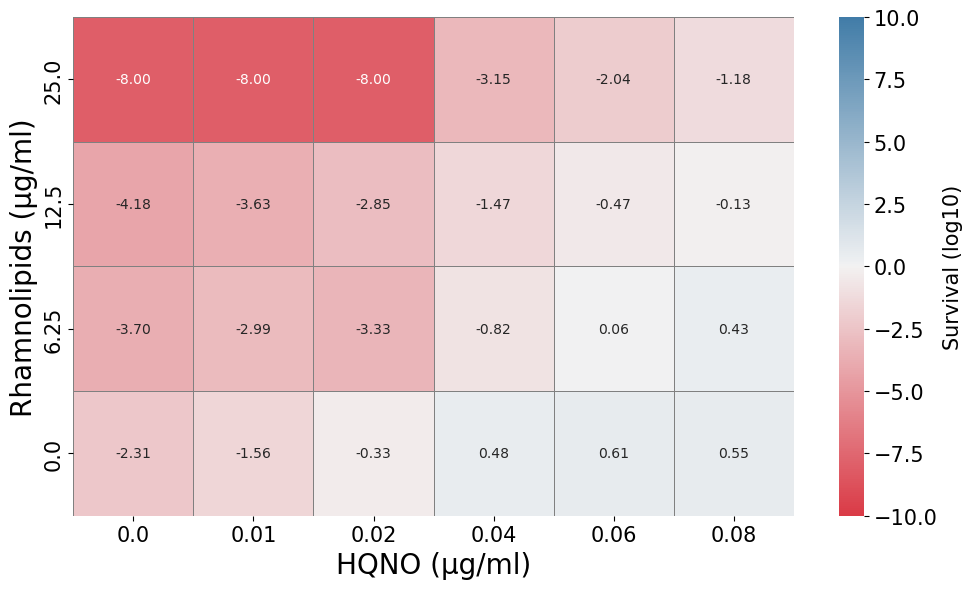

In [2]:
# Pivot survival into a concentration-by-concentration matrix
survival_rates = df.pivot_table(
    index="Rhamnolipids (µg/ml)",
    columns="HQNO (µg/ml)",
    values="Survival"
 )

# Log-transform survival for dynamic-range visualization
# Replace zeros before log10 to avoid -inf values in the heatmap
survival_rates_log = np.log10(survival_rates.replace(0, np.nan)).fillna(-8)

# Define a diverging colormap centered around 0
cmap = sns.diverging_palette(10, 240, n=21, center="light", as_cmap=True)

# Draw heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    survival_rates_log,
    annot=True,
    cmap=cmap,
    center=0,
    vmin=-10,
    vmax=10,
    fmt=".2f",
    linewidths=0.5,
    linecolor="gray",
    ax=ax,
 )

# Axis formatting
ax.set_xlabel("HQNO (µg/ml)", fontsize=20)
ax.set_ylabel("Rhamnolipids (µg/ml)", fontsize=20)
ax.invert_yaxis()
ax.tick_params(axis="both", labelsize=15)

# Colorbar formatting
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=15)
cbar.set_label("Survival (log10)", fontsize=15)

plt.tight_layout()
plt.show()